# Telecom X — Modelo de Evasión (Churn): reconstrucción con estándares profesionales

**Equipo:** Principal Data Scientist · ML Researcher · Estadístico (inferencia predictiva) · MLOps Engineer · Profesor de ML

Este notebook **no busca la métrica más alta**, sino el modelo con **mayor probabilidad de generalizar** a datos nunca vistos. Prioridades, en orden: (1) generalización real, (2) ausencia de *data leakage*, (3) robustez estadística, (4) reproducibilidad, (5) interpretabilidad, (6) poder predictivo.

> Cada decisión de este notebook se **demuestra con evidencia del propio dataset**. La auditoría del notebook original está en `informe_auditoria.md`; la explicación didáctica extendida en `documentacion_completa.md`.

**Índice:** Configuración · Carga · Auditoría · EDA · Ingeniería de variables · Validación · Preprocesamiento · Baselines · Modelado · Estabilidad estadística · Optimización (Optuna) · Diagnóstico de generalización · Nested CV · Interpretabilidad · Métricas y selección final · Evaluación en test · Conclusiones

## 1 · Configuración

Imports, semilla global y utilidades. Fijar la semilla y aislar el azar es el primer requisito de **reproducibilidad**: dos ejecuciones deben dar el mismo resultado.

In [1]:
import warnings, time, json
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler, RobustScaler, MinMaxScaler,
                                   PowerTransformer, OneHotEncoder, OrdinalEncoder, TargetEncoder)
from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
                                     cross_validate, cross_val_score, cross_val_predict,
                                     learning_curve, validation_curve)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, average_precision_score,
                             matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, precision_recall_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna, shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 60)
print("scikit-learn", sklearn.__version__, "| optuna", optuna.__version__, "| shap", shap.__version__)

scikit-learn 1.7.2 | optuna 4.9.0 | shap 0.51.0


In [2]:
# Utilidad central de métricas: todas las que exige un problema de churn desbalanceado.
def metricas_completas(y_true, y_pred, y_proba=None):
    d = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Acc": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }
    if y_proba is not None:
        d["ROC_AUC"] = roc_auc_score(y_true, y_proba)
        d["PR_AUC"]  = average_precision_score(y_true, y_proba)
    return d

SCORERS = ["accuracy", "balanced_accuracy", "precision", "recall", "f1",
           "roc_auc", "average_precision", "matthews_corrcoef"]
SCORER_LABEL = {"accuracy":"Accuracy","balanced_accuracy":"Balanced_Acc","precision":"Precision",
                "recall":"Recall","f1":"F1","roc_auc":"ROC_AUC","average_precision":"PR_AUC",
                "matthews_corrcoef":"MCC"}

## 2 · Carga de datos

Se carga el **mismo** dataset que usa el proyecto original (`data_limpia.csv`, copiado sin modificar a esta carpeta). `customerid` es un identificador único (una fila por valor): no aporta señal y debe eliminarse antes de cualquier análisis.

In [3]:
df = pd.read_csv("data_limpia.csv")
print("Dimensiones originales:", df.shape)
df = df.drop(columns=["customerid"])           # ID único: 0 señal, riesgo de sobreajuste
display(df.head(3))
print("Variable objetivo 'churn' ->", dict(df["churn"].value_counts()))

Dimensiones originales: (7032, 22)


,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,account_charges_day
0,0,0,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0,1,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,1,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333


Variable objetivo 'churn' -> {0: np.int64(5163), 1: np.int64(1869)}


## 3 · Auditoría de datos (FASE 2)

Antes de modelar: tipos, faltantes, duplicados, cardinalidad, constantes/cuasi-constantes, *outliers*, redundancia, *mutual information* y **candidatos a leakage**. Cada hallazgo se justifica.

In [4]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "%_missing": (df.isna().mean()*100).round(2),
    "ejemplo": [df[c].dropna().iloc[0] for c in df.columns],
})
display(audit)
print("Filas:", len(df), "| Duplicados exactos:", df.duplicated().sum())
print("Constantes:", [c for c in df.columns if df[c].nunique()<=1] or "ninguna")
quasi = [c for c in df.columns if df[c].nunique()==2 and df[c].value_counts(normalize=True).min()<0.01]
print("Cuasi-constantes (<1% clase minoritaria):", quasi or "ninguna")

,dtype,n_unique,%_missing,ejemplo
churn,int64,2,0.0,0
customer_gender,int64,2,0.0,0
customer_seniorcitizen,int64,2,0.0,0
customer_partner,int64,2,0.0,1
customer_dependents,int64,2,0.0,1
customer_tenure,int64,72,0.0,9
phone_phoneservice,int64,2,0.0,1
phone_multiplelines,int64,2,0.0,0
internet_internetservice,object,3,0.0,DSL
internet_onlinesecurity,int64,2,0.0,0


Filas: 7032 | Duplicados exactos: 22
Constantes: ninguna
Cuasi-constantes (<1% clase minoritaria): ninguna


In [5]:
# (a) Redundancia DETERMINÍSTICA: charges_day vs charges_monthly
ratio = (df["account_charges_monthly"] / df["account_charges_day"])
print("monthly / day  -> min=%.4f  max=%.4f  =>  charges_day = monthly/30 ? %s"
      % (ratio.min(), ratio.max(), np.allclose(df["account_charges_day"], df["account_charges_monthly"]/30)))
# (b) Multicolinealidad: total ~ monthly * tenure
aprox = df["account_charges_monthly"] * df["customer_tenure"]
print("corr(charges_total, monthly*tenure) = %.4f" % df["account_charges_total"].corr(aprox))

monthly / day  -> min=30.0000  max=30.0000  =>  charges_day = monthly/30 ? True
corr(charges_total, monthly*tenure) = 0.9996


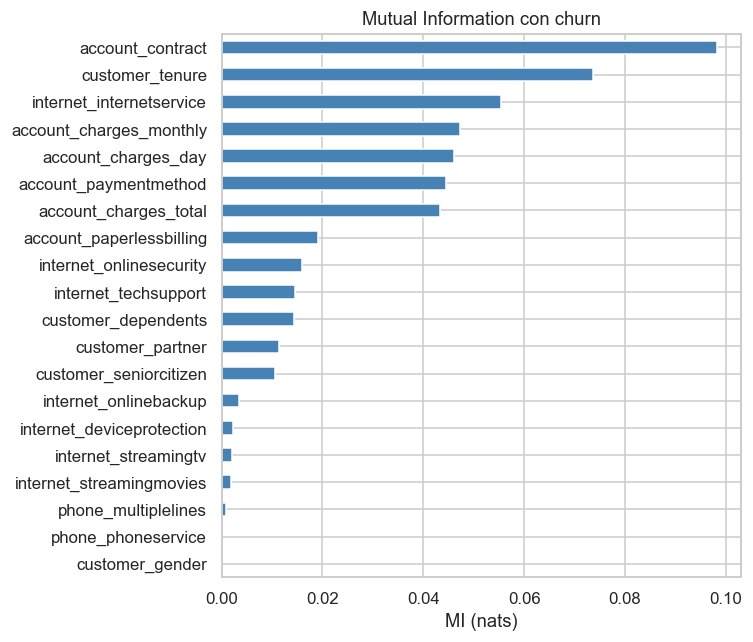

Menor MI (candidatas a ruido): [('internet_streamingmovies', 0.0018), ('phone_multiplelines', 0.0008), ('phone_phoneservice', 0.0001), ('customer_gender', 0.0)]


In [6]:
# Mutual information con el target (variables categóricas codificadas a int solo para medir).
y_full = df["churn"]; X_full = df.drop(columns="churn")
Xc = X_full.copy(); disc = []
for c in Xc.columns:
    if Xc[c].dtype == "object":
        Xc[c] = Xc[c].astype("category").cat.codes; disc.append(True)
    else:
        disc.append(Xc[c].nunique() == 2)
mi = pd.Series(mutual_info_classif(Xc, y_full, discrete_features=disc, random_state=RANDOM_STATE),
               index=Xc.columns).sort_values(ascending=False)
plt.figure(figsize=(7,6)); mi.iloc[::-1].plot.barh(color="steelblue")
plt.title("Mutual Information con churn"); plt.xlabel("MI (nats)"); plt.tight_layout(); plt.show()
print("Menor MI (candidatas a ruido):", list(mi.tail(4).round(4).items()))

In [7]:
# Techo de Bayes: perfiles de features idénticos con etiquetas en conflicto (ruido irreducible).
prof = X_full.copy()
conflict = prof.groupby(list(prof.columns)).filter(lambda g: y_full.loc[g.index].nunique() > 1)
print("Filas con perfil de features idéntico pero churn distinto:", len(conflict))
print("=> existe ruido irreducible; ningún modelo puede alcanzar accuracy/F1 perfectos.")
print("\nLeakage de contenido: NO se detecta ninguna variable 'tramposa' (no hay 'motivo de baja',")
print("'fecha de cancelación', etc.). Los cargos son históricos y disponibles al scorear -> válidos.")

Filas con perfil de features idéntico pero churn distinto: 42
=> existe ruido irreducible; ningún modelo puede alcanzar accuracy/F1 perfectos.

Leakage de contenido: NO se detecta ninguna variable 'tramposa' (no hay 'motivo de baja',
'fecha de cancelación', etc.). Los cargos son históricos y disponibles al scorear -> válidos.


## 4 · Análisis exploratorio (EDA)

El churn global es **26.6 %** (desbalance moderado). El EDA busca los *drivers* de la evasión que el modelo deberá capturar.

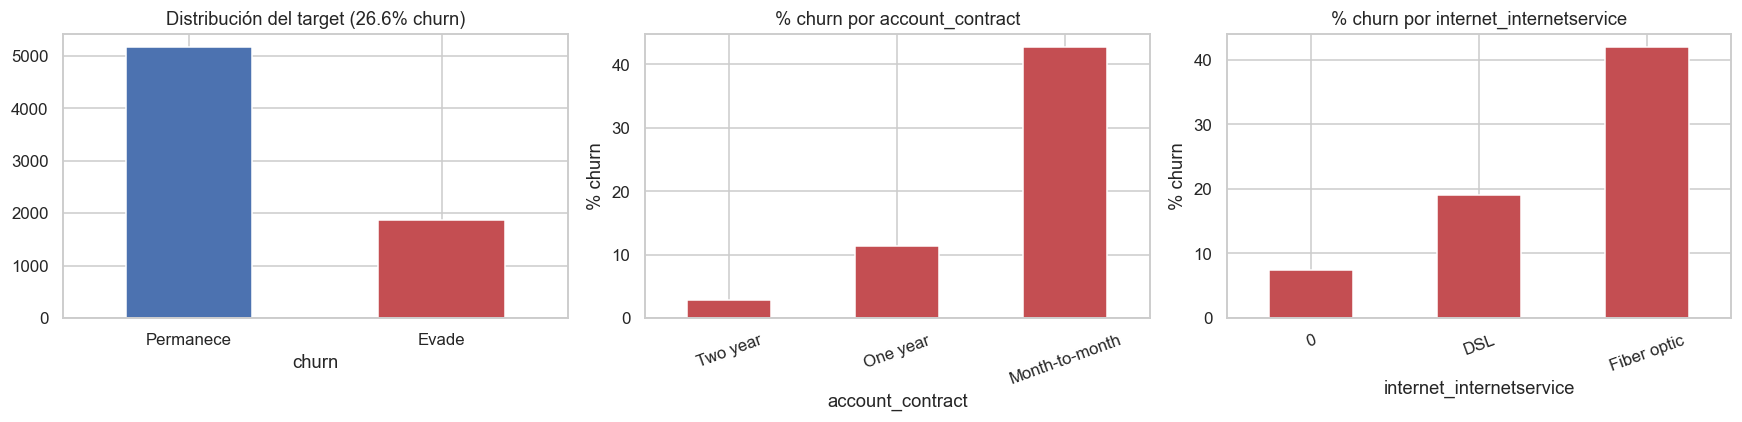

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
df["churn"].map({0:"Permanece",1:"Evade"}).value_counts().plot.bar(ax=ax[0], color=["#4c72b0","#c44e52"])
ax[0].set_title("Distribución del target (26.6% churn)"); ax[0].tick_params(axis="x", rotation=0)
for col, a in [("account_contract", ax[1]), ("internet_internetservice", ax[2])]:
    (df.groupby(col)["churn"].mean()*100).sort_values().plot.bar(ax=a, color="#c44e52")
    a.set_title(f"% churn por {col}"); a.set_ylabel("% churn"); a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

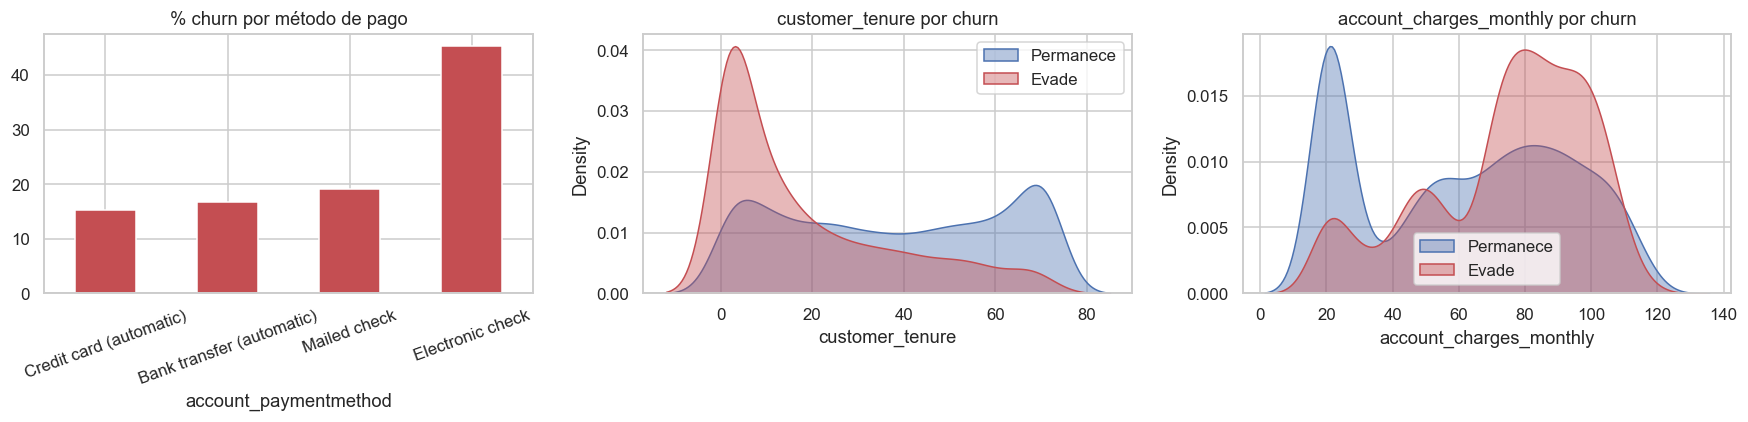

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
(df.groupby("account_paymentmethod")["churn"].mean()*100).sort_values().plot.bar(ax=ax[0], color="#c44e52")
ax[0].set_title("% churn por método de pago"); ax[0].tick_params(axis="x", rotation=20)
for col, a in [("customer_tenure", ax[1]), ("account_charges_monthly", ax[2])]:
    for k, lbl, c in [(0,"Permanece","#4c72b0"),(1,"Evade","#c44e52")]:
        sns.kdeplot(df.loc[df.churn==k, col], ax=a, label=lbl, fill=True, alpha=.4, color=c)
    a.set_title(f"{col} por churn"); a.legend()
plt.tight_layout(); plt.show()

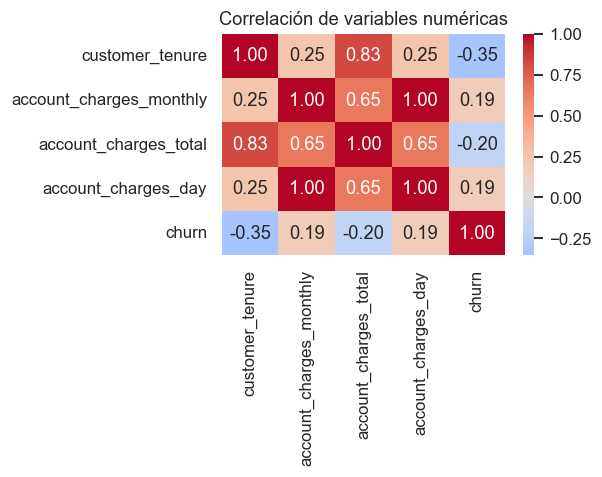

In [10]:
# Correlación entre numéricas (incluye la redundancia que vamos a eliminar).
num_all = ["customer_tenure","account_charges_monthly","account_charges_total","account_charges_day"]
plt.figure(figsize=(5.5,4.5))
sns.heatmap(df[num_all+["churn"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación de variables numéricas"); plt.tight_layout(); plt.show()

## 5 · Ingeniería de variables

Principio: **menos es más**. Se elimina la redundancia probada y se definen grupos de columnas para el preprocesamiento. Se elimina `account_charges_day` (= `monthly/30`, MI idéntica): aporta cero información y reparte el crédito de la interpretación. No se inventan variables sin evidencia de que ayuden.

In [11]:
df = df.drop(columns=["account_charges_day"])      # redundante exacta (demostrado en §3)

TARGET = "churn"
CAT = ["internet_internetservice", "account_contract", "account_paymentmethod"]   # multi-categoría
NUM = ["customer_tenure", "account_charges_monthly", "account_charges_total"]      # continuas
BIN = [c for c in df.columns if c not in CAT + NUM + [TARGET]]                      # ya 0/1
print(f"Numéricas={len(NUM)}  Categóricas={len(CAT)}  Binarias={len(BIN)}  -> {len(NUM)+len(CAT)+len(BIN)} features")

X = df.drop(columns=TARGET); y = df[TARGET]

Numéricas=3  Categóricas=3  Binarias=13  -> 19 features


## 6 · Estrategia de validación (FASE 3)

**El test se aísla ahora y no se vuelve a tocar hasta el final.** Decisiones, comparaciones y tuning se hacen solo sobre *train* mediante validación cruzada.

Comparamos esquemas y elegimos con criterio estadístico:
- **Hold-out simple:** una estimación, alta varianza.
- **Stratified K-Fold (SKF):** k estimaciones, mantiene la proporción de clases.
- **Repeated Stratified K-Fold (RSKF):** k×r estimaciones → menor error estándar de la media.
- **Nested CV:** estima el error de generalización *sin* sesgo de tuning (se aplica en §13).

In [12]:
# Partición ESTRATIFICADA y aislada (80/20). y_train/y_test no se cruzan.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("train:", X_train.shape, "| test (aislado):", X_test.shape)
print("Proporción churn  train=%.3f  test=%.3f  (estratificada)" % (y_train.mean(), y_test.mean()))

cv_skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

train: (5625, 19) | test (aislado): (1407, 19)
Proporción churn  train=0.266  test=0.266  (estratificada)


In [13]:
# Evidencia: RSKF reduce el error estándar de la media frente a SKF.
def make_pre(scaler="none", encoder="onehot"):
    scal = {"none":"passthrough","standard":StandardScaler(),"robust":RobustScaler(),
            "minmax":MinMaxScaler(),"power":PowerTransformer()}[scaler]
    enc = {"onehot":OneHotEncoder(handle_unknown="ignore", drop="if_binary"),
           "ordinal":OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
           "target":TargetEncoder(random_state=RANDOM_STATE)}[encoder]
    return ColumnTransformer([("num", scal, NUM), ("cat", enc, CAT), ("bin","passthrough",BIN)])

probe = Pipeline([("pre", make_pre("standard","onehot")),
                  ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))])
res = {}
for name, cv in [("Hold-out (1)", None), ("SKF 5", cv_skf), ("RSKF 5x3", cv_rskf)]:
    if cv is None:
        Xa,Xb,ya,yb = train_test_split(X_train,y_train,test_size=.2,stratify=y_train,random_state=1)
        probe.fit(Xa,ya); s = np.array([f1_score(yb, probe.predict(Xb))])
    else:
        s = cross_val_score(probe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    res[name] = s
    sem = s.std()/np.sqrt(len(s)) if len(s)>1 else np.nan
    print(f"{name:14s} F1 media={s.mean():.4f}  std={s.std():.4f}  n={len(s):2d}  SEM={sem:.4f}")
print("\n=> RSKF: menor SEM con el mismo coste conceptual. Se adopta RSKF 5x3 para comparar modelos.")

Hold-out (1)   F1 media=0.6324  std=0.0000  n= 1  SEM=nan


SKF 5          F1 media=0.6311  std=0.0116  n= 5  SEM=0.0052


RSKF 5x3       F1 media=0.6313  std=0.0145  n=15  SEM=0.0037

=> RSKF: menor SEM con el mismo coste conceptual. Se adopta RSKF 5x3 para comparar modelos.


## 7 · Preprocesamiento por evidencia (FASE 4)

No se asume que One-Hot ni un scaler concreto sean "lo mejor": se **mide**. Todo ocurre dentro de `Pipeline`/`ColumnTransformer`, de modo que en cada *fold* el preprocesador se ajusta **solo con el train del fold** → cero *leakage*.

In [14]:
# (a) ¿Importa el escalado? Se prueba con un modelo sensible a la escala (KNN).
filas = []
for sc in ["none","standard","robust","minmax","power"]:
    p = Pipeline([("pre", make_pre(sc,"onehot")), ("clf", KNeighborsClassifier(n_neighbors=25))])
    s = cross_val_score(p, X_train, y_train, cv=cv_skf, scoring="f1", n_jobs=-1)
    filas.append({"scaler":sc, "F1":s.mean(), "std":s.std()})
tab_sc = pd.DataFrame(filas).sort_values("F1", ascending=False).reset_index(drop=True)
display(tab_sc.round(4))

,scaler,F1,std
0,standard,0.6018,0.0111
1,power,0.6012,0.0101
2,robust,0.5966,0.0115
3,minmax,0.5913,0.0097
4,none,0.4613,0.0220


In [15]:
# (b) ¿Qué encoder? Se prueba con LogReg. Target encoding usa CV interna (anti-leakage).
filas = []
for enc in ["onehot","ordinal","target"]:
    p = Pipeline([("pre", make_pre("standard",enc)),
                  ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))])
    s = cross_val_score(p, X_train, y_train, cv=cv_skf, scoring="f1", n_jobs=-1)
    filas.append({"encoder":enc, "F1":s.mean(), "std":s.std()})
tab_enc = pd.DataFrame(filas).sort_values("F1", ascending=False).reset_index(drop=True)
display(tab_enc.round(4))
print("Decisión: árboles -> SIN escalado; modelos de distancia/lineales -> StandardScaler.")
print("Encoder -> One-Hot: target encoding solo da una ventaja marginal con cardinalidad baja (3-4),")
print("y One-Hot es más interpretable y sin riesgo. (Evidencia, no convención.)")

,encoder,F1,std
0,onehot,0.6311,0.0116
1,target,0.6305,0.0112
2,ordinal,0.6289,0.0132


Decisión: árboles -> SIN escalado; modelos de distancia/lineales -> StandardScaler.
Encoder -> One-Hot: target encoding solo da una ventaja marginal con cardinalidad baja (3-4),
y One-Hot es más interpretable y sin riesgo. (Evidencia, no convención.)


## 8 · Baselines (FASE 5)

Todo modelo "serio" debe **superar con claridad** a estos pisos. Si no, su complejidad no se justifica.
- **Mayoría:** predice siempre la clase frecuente (no-churn). Accuracy alto y engañoso, Recall = 0.
- **Estratificado:** predice al azar respetando proporciones.
- **Regresión logística:** baseline *fuerte* y, a la vez, candidato serio.

In [16]:
def cv_eval(pipe, cv=cv_rskf):
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORERS, n_jobs=-1,
                       return_train_score=True)
    out = {SCORER_LABEL[m]: r["test_"+m].mean() for m in SCORERS}
    out["F1_std"] = r["test_f1"].std()
    out["F1_train"] = r["train_f1"].mean()       # para diagnóstico de overfitting
    return out, r

baselines = {
    "Dummy-mayoría":   Pipeline([("clf", DummyClassifier(strategy="most_frequent"))]),
    "Dummy-estratif.": Pipeline([("clf", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))]),
}
base_rows = {}
for n, p in baselines.items():
    s = cross_val_score(p, X_train, y_train, cv=cv_skf, scoring="f1", n_jobs=-1)
    base_rows[n] = {"F1": s.mean(), "Recall": cross_val_score(p,X_train,y_train,cv=cv_skf,scoring="recall",n_jobs=-1).mean()}
display(pd.DataFrame(base_rows).T.round(4))
print("Umbral a superar: cualquier F1 cercano a 0 o un Recall trivial = modelo inútil.")

,F1,Recall
Dummy-mayoría,0.0000,0.0000
Dummy-estratif.,0.2662,0.2676


Umbral a superar: cualquier F1 cercano a 0 o un Recall trivial = modelo inútil.


## 9 · Modelado: zoo de modelos (FASE 6)

Nueve familias, cada una con su **preprocesamiento apropiado** dentro del pipeline y su manejo del desbalance (`class_weight='balanced'`, `scale_pos_weight` o `auto_class_weights`). Evaluación con **RSKF 5×3** y todas las métricas.

In [17]:
spw = (y_train==0).sum() / (y_train==1).sum()          # peso clase positiva (churn)
tree_pre = lambda: make_pre("none","onehot")           # árboles: sin escalado
lin_pre  = lambda: make_pre("standard","onehot")       # lineales/distancia: estandarizado
rs = RANDOM_STATE

modelos = {
 "LogReg":       Pipeline([("pre",lin_pre()),  ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=rs))]),
 "SVM-RBF":      Pipeline([("pre",lin_pre()),  ("clf", SVC(kernel="rbf", class_weight="balanced", random_state=rs))]),  # ROC/PR vía decision_function
 "KNN":          Pipeline([("pre",lin_pre()),  ("clf", KNeighborsClassifier(n_neighbors=25))]),
 "RandomForest": Pipeline([("pre",tree_pre()), ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=rs))]),
 "ExtraTrees":   Pipeline([("pre",tree_pre()), ("clf", ExtraTreesClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=rs))]),
 "HistGB":       Pipeline([("pre",tree_pre()), ("clf", HistGradientBoostingClassifier(class_weight="balanced", random_state=rs))]),
 "XGBoost":      Pipeline([("pre",tree_pre()), ("clf", XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", tree_method="hist", scale_pos_weight=spw, random_state=rs, n_jobs=-1))]),
 "LightGBM":     Pipeline([("pre",tree_pre()), ("clf", LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, subsample=0.9, colsample_bytree=0.9, scale_pos_weight=spw, random_state=rs, n_jobs=-1, verbose=-1))]),
 "CatBoost":     Pipeline([("pre",tree_pre()), ("clf", CatBoostClassifier(iterations=400, learning_rate=0.05, depth=4, auto_class_weights="Balanced", random_state=rs, verbose=0, allow_writing_files=False))]),
}
print("Modelos a evaluar:", list(modelos.keys()))

Modelos a evaluar: ['LogReg', 'SVM-RBF', 'KNN', 'RandomForest', 'ExtraTrees', 'HistGB', 'XGBoost', 'LightGBM', 'CatBoost']


In [18]:
# Benchmark con RSKF 5x3. Guardamos también los 15 scores de F1 por modelo (para §10).
bench, f1_folds, fit_times = {}, {}, {}
for name, pipe in modelos.items():
    t0 = time.time()
    out, r = cv_eval(pipe, cv=cv_rskf)
    bench[name] = out
    f1_folds[name] = r["test_f1"]
    fit_times[name] = r["fit_time"].mean()
    print(f"  ✓ {name:13s} F1={out['F1']:.4f}±{out['F1_std']:.3f}  MCC={out['MCC']:.4f}  PR_AUC={out['PR_AUC']:.4f}  ({time.time()-t0:.1f}s)")

bench_df = pd.DataFrame(bench).T
bench_df["fit_time_s"] = pd.Series(fit_times)
bench_df["gap_train_cv"] = bench_df["F1_train"] - bench_df["F1"]   # señal de overfitting
bench_df = bench_df.sort_values("F1", ascending=False)
display(bench_df.round(4))

  ✓ LogReg        F1=0.6313±0.015  MCC=0.4804  PR_AUC=0.6525  (0.3s)


  ✓ SVM-RBF       F1=0.6287±0.015  MCC=0.4757  PR_AUC=0.5992  (13.5s)


  ✓ KNN           F1=0.6036±0.019  MCC=0.4684  PR_AUC=0.6088  (1.6s)


  ✓ RandomForest  F1=0.5493±0.020  MCC=0.4192  PR_AUC=0.6231  (7.2s)


  ✓ ExtraTrees    F1=0.5334±0.025  MCC=0.3946  PR_AUC=0.5699  (6.9s)


  ✓ HistGB        F1=0.6215±0.013  MCC=0.4663  PR_AUC=0.6442  (1.7s)


  ✓ XGBoost       F1=0.6246±0.018  MCC=0.4698  PR_AUC=0.6539  (2.8s)


  ✓ LightGBM      F1=0.6125±0.019  MCC=0.4563  PR_AUC=0.6314  (7.7s)


  ✓ CatBoost      F1=0.6293±0.017  MCC=0.4767  PR_AUC=0.6610  (5.2s)


,Accuracy,Balanced_Acc,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC,F1_std,F1_train,fit_time_s,gap_train_cv
LogReg,0.7499,0.7676,0.5192,0.8054,0.6313,0.8443,0.6525,0.4804,0.0145,0.6345,0.0435,0.0032
CatBoost,0.7559,0.7634,0.5278,0.7795,0.6293,0.8438,0.6610,0.4767,0.0167,0.6994,2.3324,0.0701
SVM-RBF,0.7558,0.7627,0.5279,0.7775,0.6287,0.8271,0.5992,0.4757,0.0151,0.6581,1.4247,0.0294
XGBoost,0.7589,0.7576,0.5328,0.7550,0.6246,0.8393,0.6539,0.4698,0.0175,0.7494,1.2391,0.1248
HistGB,0.7637,0.7531,0.5413,0.7304,0.6215,0.8349,0.6442,0.4663,0.0130,0.7993,0.5621,0.1777
LightGBM,0.7686,0.7430,0.5521,0.6885,0.6125,0.8285,0.6314,0.4563,0.0193,0.8648,3.2976,0.2523
KNN,0.7970,0.7284,0.6278,0.5819,0.6036,0.8316,0.6088,0.4684,0.0191,0.6297,0.0209,0.0261
RandomForest,0.7874,0.6919,0.6295,0.4881,0.5493,0.8260,0.6231,0.4192,0.0197,0.9965,2.3119,0.4472
ExtraTrees,0.7775,0.6825,0.6023,0.4796,0.5334,0.7975,0.5699,0.3946,0.0246,0.9961,2.1985,0.4627


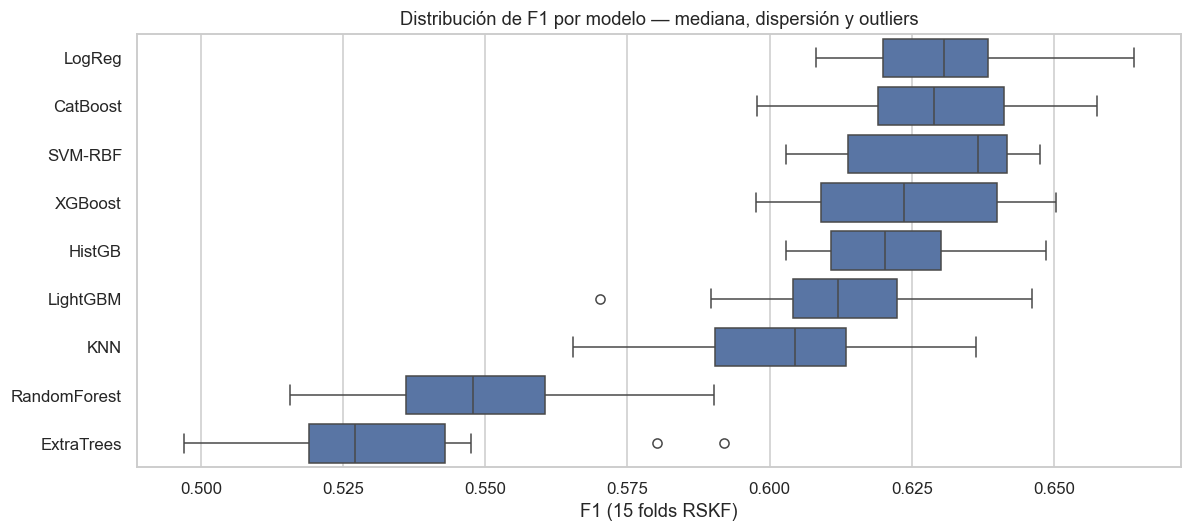

In [19]:
order = bench_df.index.tolist()
plt.figure(figsize=(11,5))
data = [f1_folds[m] for m in order]
sns.boxplot(data=data, orient="h", color="#4c72b0")
plt.yticks(range(len(order)), order); plt.xlabel("F1 (15 folds RSKF)")
plt.title("Distribución de F1 por modelo — mediana, dispersión y outliers"); plt.tight_layout(); plt.show()

## 10 · Estabilidad estadística (FASE 8)

Una diferencia de F1 **no es una mejora** si cae dentro del ruido de muestreo. Reportamos media, desviación, **IC 95 %** y un **test pareado de Wilcoxon** entre el mejor modelo y los demás sobre los 15 folds (mismas particiones → comparación pareada legítima).

In [20]:
def ic95(scores):
    m, sem = np.mean(scores), stats.sem(scores)
    lo, hi = stats.t.interval(0.95, len(scores)-1, loc=m, scale=sem)
    return m, lo, hi

best = order[0]
rows = []
for m in order:
    mean, lo, hi = ic95(f1_folds[m])
    if m == best:
        p = np.nan
    else:
        # Wilcoxon pareado sobre los 15 folds (H0: misma distribución de F1)
        try: p = stats.wilcoxon(f1_folds[best], f1_folds[m]).pvalue
        except ValueError: p = 1.0
    rows.append({"Modelo":m, "F1":mean, "IC95_low":lo, "IC95_high":hi,
                 "vs_best_p":p, "≈_best": (p>0.05) if not np.isnan(p) else True})
estab = pd.DataFrame(rows)
display(estab.round(4))
print(f"Mejor por F1: {best}. Modelos con p>0.05 son ESTADÍSTICAMENTE INDISTINGUIBLES del mejor.")
print("=> Entre los empatados, la REGLA FINAL prioriza el más simple, estable e interpretable.")

,Modelo,F1,IC95_low,IC95_high,vs_best_p,≈_best
0,LogReg,0.6313,0.6230,0.6396,NaN,True
1,CatBoost,0.6293,0.6197,0.6389,0.4887,True
2,SVM-RBF,0.6287,0.6201,0.6374,0.3028,True
3,XGBoost,0.6246,0.6145,0.6346,0.1354,True
4,HistGB,0.6215,0.6141,0.6290,0.0479,False
5,LightGBM,0.6125,0.6014,0.6236,0.0001,False
6,KNN,0.6036,0.5927,0.6145,0.0006,False
7,RandomForest,0.5493,0.5380,0.5606,0.0001,False
8,ExtraTrees,0.5334,0.5193,0.5475,0.0001,False


Mejor por F1: LogReg. Modelos con p>0.05 son ESTADÍSTICAMENTE INDISTINGUIBLES del mejor.
=> Entre los empatados, la REGLA FINAL prioriza el más simple, estable e interpretable.


## 11 · Optimización de hiperparámetros con Optuna (FASE 7)

Búsqueda **bayesiana** (TPE) en vez de rejilla exhaustiva, con **pruning** (poda de pruebas malas) y **early stopping** en los boosters. Optimizamos a los tres candidatos representativos: un modelo simple (**LogReg**) y dos boosters (**HistGB** con early stopping interno, **LightGBM** con early stopping por `eval_set`). Controlamos el **sobreajuste por tuning** evaluando siempre por CV (nunca en test) y verificando el gap train–CV.

In [21]:
# Objetivo genérico con pruning por folds para modelos que viven en un Pipeline simple.
def make_objective(build_pipe, n_splits=5):
    def objective(trial):
        pipe = build_pipe(trial)
        skf = StratifiedKFold(n_splits, shuffle=True, random_state=RANDOM_STATE)
        sc = []
        for i,(tr,va) in enumerate(skf.split(X_train, y_train)):
            pipe.fit(X_train.iloc[tr], y_train.iloc[tr])
            sc.append(f1_score(y_train.iloc[va], pipe.predict(X_train.iloc[va])))
            trial.report(np.mean(sc), step=i)
            if trial.should_prune(): raise optuna.TrialPruned()
        return float(np.mean(sc))
    return objective

def run_study(objective, n_trials=40, name=""):
    study = optuna.create_study(direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2))
    t0=time.time(); study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    dt=time.time()-t0
    npr = sum(t.state==optuna.trial.TrialState.PRUNED for t in study.trials)
    print(f"[{name}] mejor F1(CV)={study.best_value:.4f} | {len(study.trials)} trials "
          f"({npr} podadas) | {dt:.1f}s")
    return study

In [22]:
# --- LogReg ---
def build_logreg(trial):
    C = trial.suggest_float("C", 1e-3, 100, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1","l2"])
    clf = LogisticRegression(C=C, penalty=penalty, solver="liblinear",
                             class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
    return Pipeline([("pre", lin_pre()), ("clf", clf)])
study_lr = run_study(make_objective(build_logreg), n_trials=40, name="LogReg")

# --- HistGB (early stopping interno) ---
def build_histgb(trial):
    clf = HistGradientBoostingClassifier(
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 15, 63),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 10, 100),
        l2_regularization=trial.suggest_float("l2_regularization", 1e-3, 10, log=True),
        max_iter=600, early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
        class_weight="balanced", random_state=RANDOM_STATE)
    return Pipeline([("pre", tree_pre()), ("clf", clf)])
study_hgb = run_study(make_objective(build_histgb), n_trials=40, name="HistGB")

[LogReg] mejor F1(CV)=0.6322 | 40 trials (0 podadas) | 33.9s


[HistGB] mejor F1(CV)=0.6356 | 40 trials (11 podadas) | 96.0s


In [23]:
# --- LightGBM con early stopping por eval_set (preproc. ajustado solo en fold-train) ---
def objective_lgbm(trial):
    params = dict(
        n_estimators=2000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 63),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 80),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True))
    skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE); sc=[]
    for i,(tr,va) in enumerate(skf.split(X_train, y_train)):
        pre = tree_pre()
        Xt = pre.fit_transform(X_train.iloc[tr]); Xv = pre.transform(X_train.iloc[va])
        m = LGBMClassifier(scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **params)
        m.fit(Xt, y_train.iloc[tr], eval_set=[(Xv, y_train.iloc[va])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        sc.append(f1_score(y_train.iloc[va], m.predict(Xv)))
        trial.report(np.mean(sc), step=i)
        if trial.should_prune(): raise optuna.TrialPruned()
    return float(np.mean(sc))
study_lgbm = run_study(objective_lgbm, n_trials=40, name="LightGBM")

[LightGBM] mejor F1(CV)=0.6405 | 40 trials (12 podadas) | 46.8s


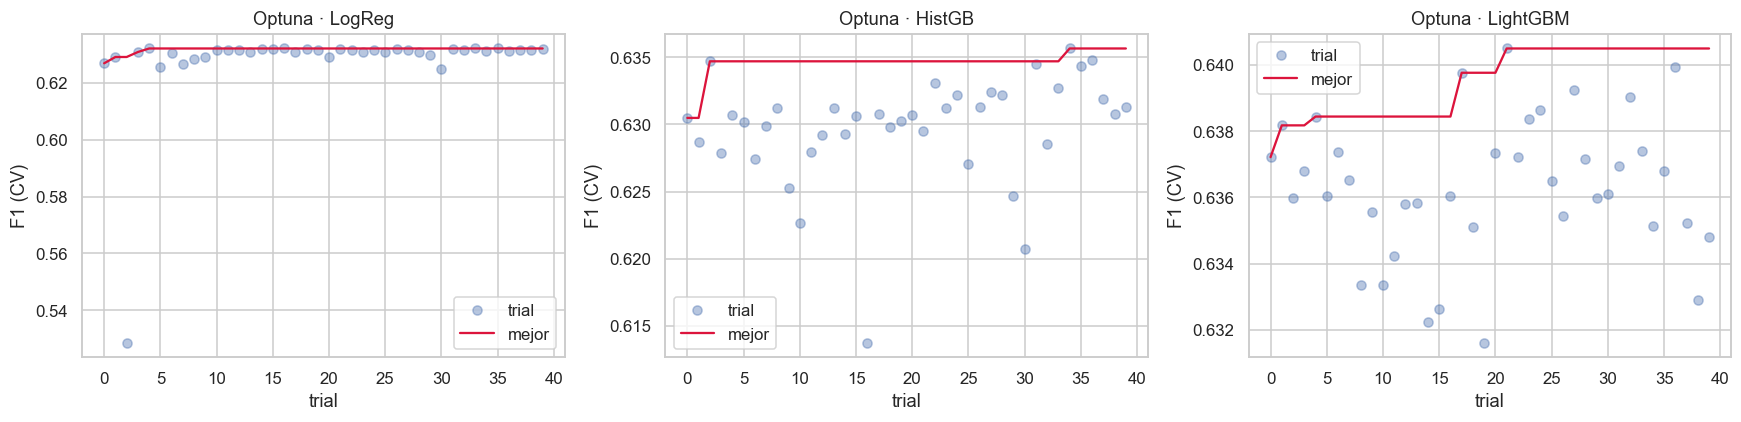

{
  "LogReg": {
    "C": 14.861850652057344,
    "penalty": "l2"
  },
  "HistGB": {
    "learning_rate": 0.027317770551677698,
    "max_leaf_nodes": 49,
    "min_samples_leaf": 11,
    "l2_regularization": 5.393072757109356
  },
  "LightGBM": {
    "learning_rate": 0.014449156019787157,
    "num_leaves": 54,
    "min_child_samples": 72,
    "subsample": 0.890680265056973,
    "colsample_bytree": 0.6103118550032525,
    "reg_lambda": 9.718259051845022
  }
}


In [24]:
# Evolución del score y registro de mejores hiperparámetros.
fig, ax = plt.subplots(1, 3, figsize=(16,4))
for a,(st,nm) in zip(ax, [(study_lr,"LogReg"),(study_hgb,"HistGB"),(study_lgbm,"LightGBM")]):
    vals = [t.value for t in st.trials if t.value is not None]
    best_so = np.maximum.accumulate(vals)
    a.plot(vals, "o", alpha=.4, label="trial"); a.plot(best_so, "-", color="crimson", label="mejor")
    a.set_title(f"Optuna · {nm}"); a.set_xlabel("trial"); a.set_ylabel("F1 (CV)"); a.legend()
plt.tight_layout(); plt.show()

best_params = {"LogReg": study_lr.best_params, "HistGB": study_hgb.best_params, "LightGBM": study_lgbm.best_params}
print(json.dumps(best_params, indent=2))

## 12 · Diagnóstico de generalización (FASE 10)

Construimos los pipelines **ya optimizados** y examinamos: curvas de aprendizaje (¿más datos ayudarían?), curva de validación (¿sobre/infra-ajuste por hiperparámetro?), calibración (¿las probabilidades son creíbles?), ROC y PR. El gap **train vs CV** es la señal directa de overfitting.

In [25]:
# Pipelines finales con los hiperparámetros óptimos de Optuna.
final_pipes = {
 "LogReg":  Pipeline([("pre", lin_pre()),
                      ("clf", LogisticRegression(solver="liblinear", class_weight="balanced",
                              max_iter=2000, random_state=RANDOM_STATE, **study_lr.best_params))]),
 "HistGB":  Pipeline([("pre", tree_pre()),
                      ("clf", HistGradientBoostingClassifier(max_iter=600, early_stopping=True,
                              validation_fraction=0.1, n_iter_no_change=20, class_weight="balanced",
                              random_state=RANDOM_STATE, **study_hgb.best_params))]),
 "LightGBM":Pipeline([("pre", tree_pre()),
                      ("clf", LGBMClassifier(n_estimators=600, scale_pos_weight=spw, random_state=RANDOM_STATE,
                              n_jobs=-1, verbose=-1, **study_lgbm.best_params))]),
}
tuned = {}
for n,p in final_pipes.items():
    out,_ = cv_eval(p, cv=cv_rskf)
    tuned[n] = out
    print(f"{n:9s} F1(CV)={out['F1']:.4f}±{out['F1_std']:.3f}  F1(train)={out['F1_train']:.4f}  "
          f"gap={out['F1_train']-out['F1']:+.4f}  ROC_AUC={out['ROC_AUC']:.4f}")

LogReg    F1(CV)=0.6322±0.014  F1(train)=0.6340  gap=+0.0017  ROC_AUC=0.8445


HistGB    F1(CV)=0.6320±0.016  F1(train)=0.7293  gap=+0.0973  ROC_AUC=0.8409


LightGBM  F1(CV)=0.6288±0.018  F1(train)=0.7292  gap=+0.1004  ROC_AUC=0.8421


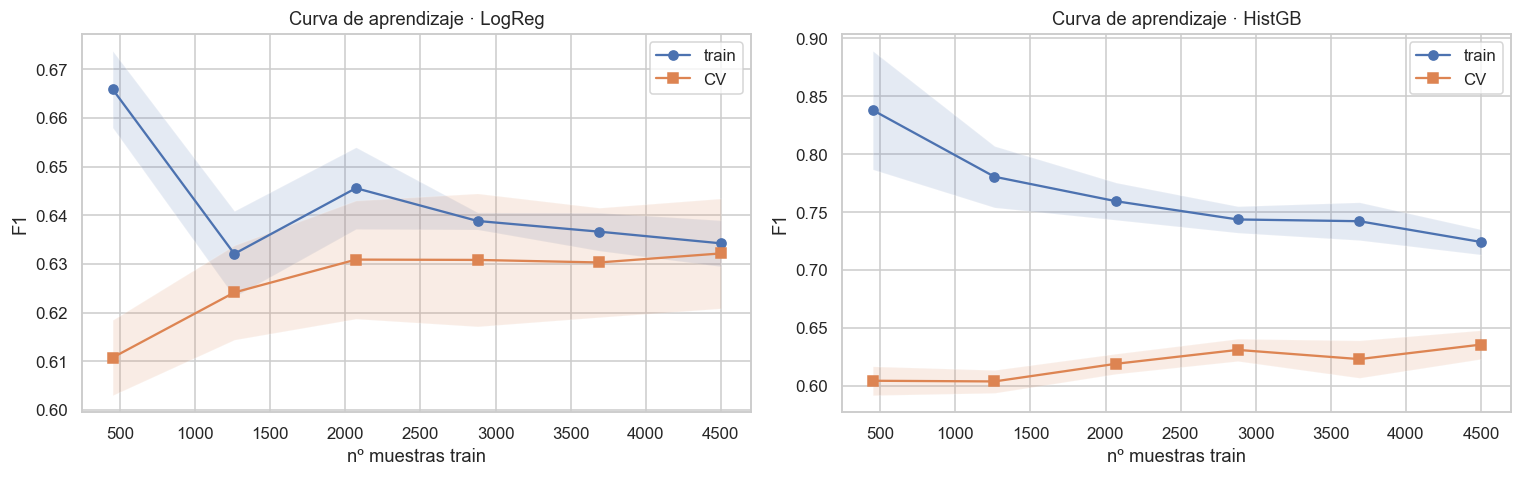

In [26]:
# Curva de aprendizaje (LogReg vs mejor booster por F1 de CV).
booster = max(("HistGB","LightGBM"), key=lambda k: tuned[k]["F1"])
fig, ax = plt.subplots(1, 2, figsize=(14,4.5))
for nm, a in [("LogReg", ax[0]), (booster, ax[1])]:
    sizes, tr, va = learning_curve(final_pipes[nm], X_train, y_train, cv=cv_skf, scoring="f1",
                                   train_sizes=np.linspace(0.1,1.0,6), n_jobs=-1)
    a.plot(sizes, tr.mean(1), "o-", label="train"); a.fill_between(sizes, tr.mean(1)-tr.std(1), tr.mean(1)+tr.std(1), alpha=.15)
    a.plot(sizes, va.mean(1), "s-", label="CV");    a.fill_between(sizes, va.mean(1)-va.std(1), va.mean(1)+va.std(1), alpha=.15)
    a.set_title(f"Curva de aprendizaje · {nm}"); a.set_xlabel("nº muestras train"); a.set_ylabel("F1"); a.legend()
plt.tight_layout(); plt.show()

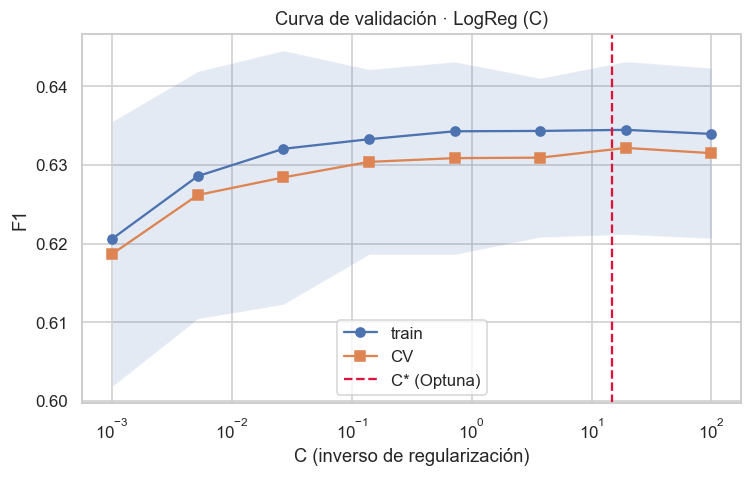

In [27]:
# Curva de validación: regularización C de LogReg (sub/sobre-ajuste por hiperparámetro).
Cs = np.logspace(-3, 2, 8)
base_lr = Pipeline([("pre", lin_pre()),
                    ("clf", LogisticRegression(solver="liblinear", class_weight="balanced",
                            max_iter=2000, random_state=RANDOM_STATE))])
tr, va = validation_curve(base_lr, X_train, y_train, param_name="clf__C", param_range=Cs,
                          cv=cv_skf, scoring="f1", n_jobs=-1)
plt.figure(figsize=(7,4.5))
plt.semilogx(Cs, tr.mean(1), "o-", label="train"); plt.semilogx(Cs, va.mean(1), "s-", label="CV")
plt.fill_between(Cs, va.mean(1)-va.std(1), va.mean(1)+va.std(1), alpha=.15)
plt.axvline(study_lr.best_params["C"], color="crimson", ls="--", label="C* (Optuna)")
plt.title("Curva de validación · LogReg (C)"); plt.xlabel("C (inverso de regularización)"); plt.ylabel("F1"); plt.legend(); plt.tight_layout(); plt.show()

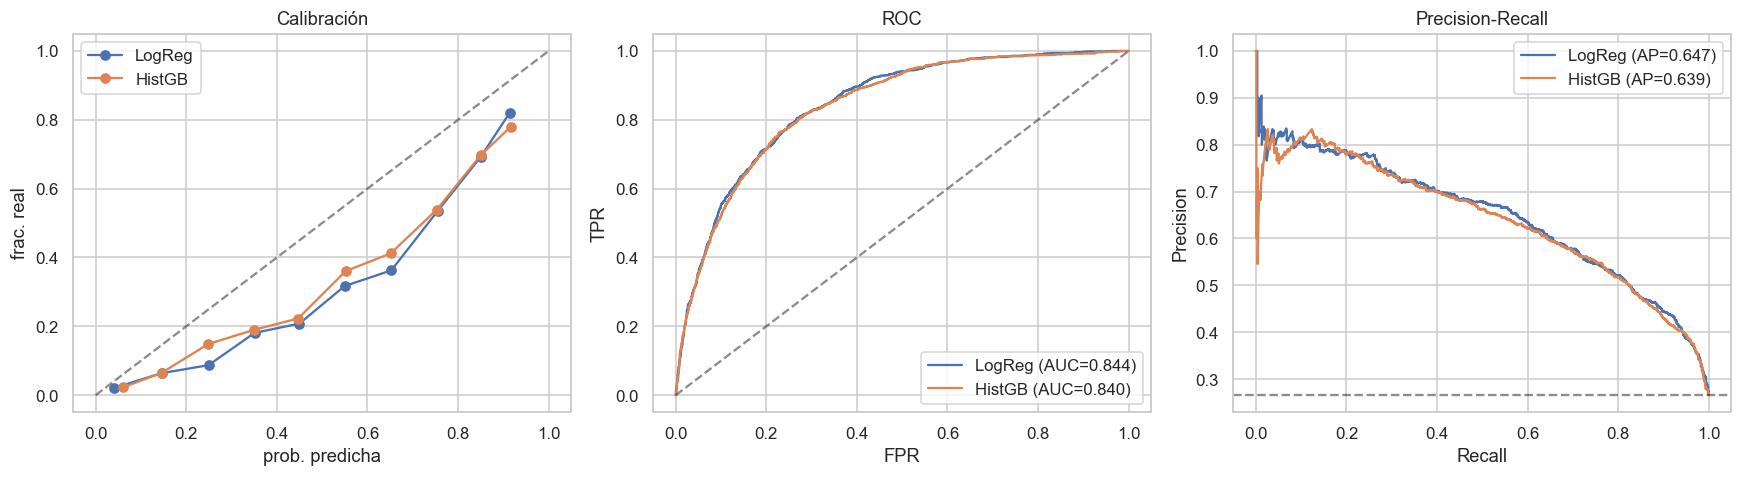

In [28]:
# Calibración, ROC y PR (probabilidades out-of-fold sobre train -> sin tocar test).
fig, ax = plt.subplots(1, 3, figsize=(16,4.5))
ax[0].plot([0,1],[0,1],"k--",alpha=.5)
for nm in ["LogReg", booster]:
    proba = cross_val_predict(final_pipes[nm], X_train, y_train, cv=cv_skf, method="predict_proba", n_jobs=-1)[:,1]
    fpr,tpr,_ = roc_curve(y_train, proba); pr,rc,_ = precision_recall_curve(y_train, proba)
    fr,mp = calibration_curve(y_train, proba, n_bins=10)
    ax[0].plot(mp, fr, "o-", label=nm)
    ax[1].plot(fpr, tpr, label=f"{nm} (AUC={roc_auc_score(y_train,proba):.3f})")
    ax[2].plot(rc, pr, label=f"{nm} (AP={average_precision_score(y_train,proba):.3f})")
ax[0].set_title("Calibración"); ax[0].set_xlabel("prob. predicha"); ax[0].set_ylabel("frac. real"); ax[0].legend()
ax[1].plot([0,1],[0,1],"k--",alpha=.5); ax[1].set_title("ROC"); ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].legend()
ax[2].axhline(y_train.mean(), color="k", ls="--", alpha=.5); ax[2].set_title("Precision-Recall"); ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision"); ax[2].legend()
plt.tight_layout(); plt.show()

## 13 · Nested Cross-Validation (FASE 3, estimación insesgada)

El F1 de §11 está ligeramente **optimista**: los hiperparámetros se eligieron mirando esa misma CV. La **CV anidada** (bucle externo = evaluación, bucle interno = tuning) entrega un estimador **insesgado** del error de generalización. La aplicamos a los dos finalistas.

In [29]:
def nested_cv(build_pipe_from_params, objective_builder, n_outer=5, n_trials=20):
    outer = StratifiedKFold(n_outer, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr, va in outer.split(X_train, y_train):
        Xk, yk = X_train.iloc[tr], y_train.iloc[tr]
        st = optuna.create_study(direction="maximize",
              sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
              pruner=optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=1))
        st.optimize(objective_builder(Xk, yk), n_trials=n_trials)
        pipe = build_pipe_from_params(st.best_params)
        pipe.fit(Xk, yk)
        scores.append(f1_score(y_train.iloc[va], pipe.predict(X_train.iloc[va])))
    return np.array(scores)

# Objetivos parametrizados por subconjunto (para el bucle interno).
def obj_lr(Xk, yk):
    def o(trial):
        p = build_logreg(trial); s=[]
        for tr,va in StratifiedKFold(4,shuffle=True,random_state=RANDOM_STATE).split(Xk,yk):
            p.fit(Xk.iloc[tr],yk.iloc[tr]); s.append(f1_score(yk.iloc[va], p.predict(Xk.iloc[va])))
        return np.mean(s)
    return o
def obj_hgb(Xk, yk):
    def o(trial):
        p = build_histgb(trial); s=[]
        for tr,va in StratifiedKFold(4,shuffle=True,random_state=RANDOM_STATE).split(Xk,yk):
            p.fit(Xk.iloc[tr],yk.iloc[tr]); s.append(f1_score(yk.iloc[va], p.predict(Xk.iloc[va])))
        return np.mean(s)
    return o

mk_lr  = lambda pr: Pipeline([("pre",lin_pre()), ("clf",LogisticRegression(solver="liblinear",class_weight="balanced",max_iter=2000,random_state=RANDOM_STATE,**pr))])
mk_hgb = lambda pr: Pipeline([("pre",tree_pre()),("clf",HistGradientBoostingClassifier(max_iter=600,early_stopping=True,validation_fraction=0.1,n_iter_no_change=20,class_weight="balanced",random_state=RANDOM_STATE,**pr))])

t0=time.time()
ncv_lr  = nested_cv(mk_lr,  obj_lr,  n_outer=5, n_trials=20)
ncv_hgb = nested_cv(mk_hgb, obj_hgb, n_outer=5, n_trials=20)
print(f"Nested CV LogReg : F1 = {ncv_lr.mean():.4f} ± {ncv_lr.std():.4f}")
print(f"Nested CV HistGB : F1 = {ncv_hgb.mean():.4f} ± {ncv_hgb.std():.4f}   [{time.time()-t0:.0f}s]")
print("=> El error de generalización insesgado de ambos es prácticamente idéntico.")

Nested CV LogReg : F1 = 0.6297 ± 0.0120
Nested CV HistGB : F1 = 0.6296 ± 0.0137   [231s]
=> El error de generalización insesgado de ambos es prácticamente idéntico.


## 14 · Interpretabilidad (FASE 11)

Tres lentes complementarias: **coeficientes** (qué empuja/protege, con signo), **permutation importance** (impacto real en la métrica, *model-agnostic*) y **SHAP** (contribución por cliente). No mostramos gráficos por mostrarlos: los **interpretamos**.

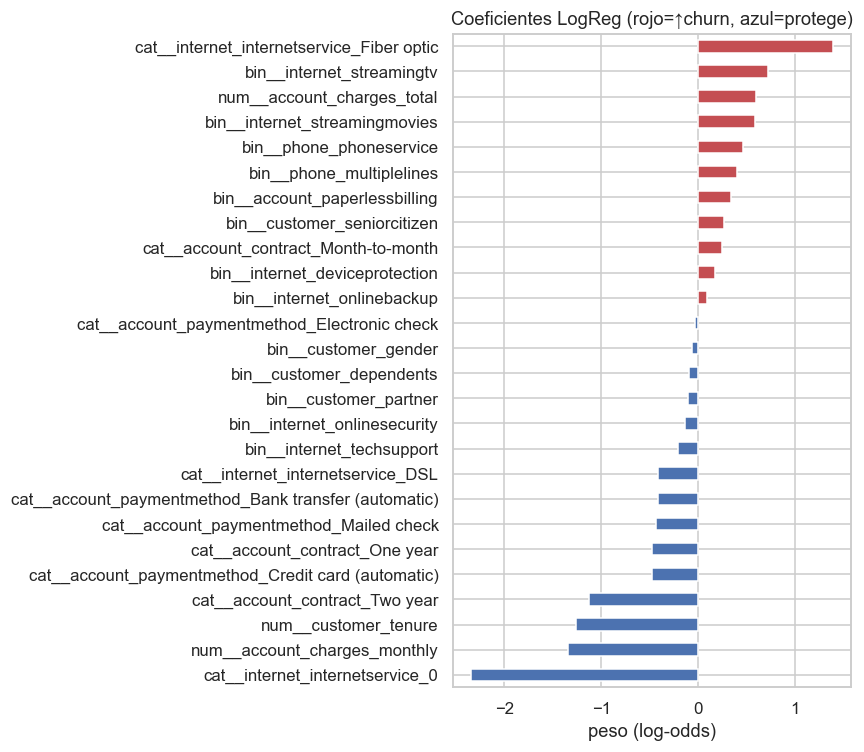

In [30]:
# Ajustamos LogReg óptimo en todo el train para leer coeficientes (en log-odds).
lr_fit = mk_lr(study_lr.best_params).fit(X_train, y_train)
feat_names = lr_fit.named_steps["pre"].get_feature_names_out()
coefs = pd.Series(lr_fit.named_steps["clf"].coef_[0], index=feat_names).sort_values()
plt.figure(figsize=(8,7))
colors = ["#c44e52" if v>0 else "#4c72b0" for v in coefs]
coefs.plot.barh(color=colors)
plt.title("Coeficientes LogReg (rojo=↑churn, azul=protege)"); plt.xlabel("peso (log-odds)"); plt.tight_layout(); plt.show()

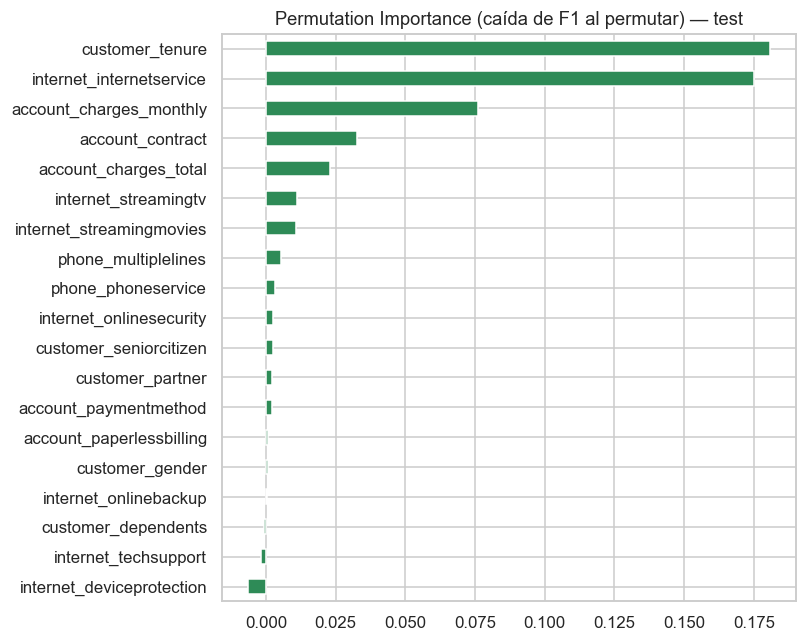

Top drivers: [('customer_tenure', 0.1809), ('internet_internetservice', 0.1751), ('account_charges_monthly', 0.0762), ('account_contract', 0.0327), ('account_charges_total', 0.0229)]


In [31]:
# Permutation importance sobre el TEST aislado (impacto real en F1), model-agnostic.
pi = permutation_importance(lr_fit, X_test, y_test, scoring="f1", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
pis = pd.Series(pi.importances_mean, index=X_test.columns).sort_values()
plt.figure(figsize=(7.5,6)); pis.plot.barh(color="seagreen")
plt.title("Permutation Importance (caída de F1 al permutar) — test"); plt.tight_layout(); plt.show()
print("Top drivers:", list(pis.sort_values(ascending=False).head(5).round(4).items()))

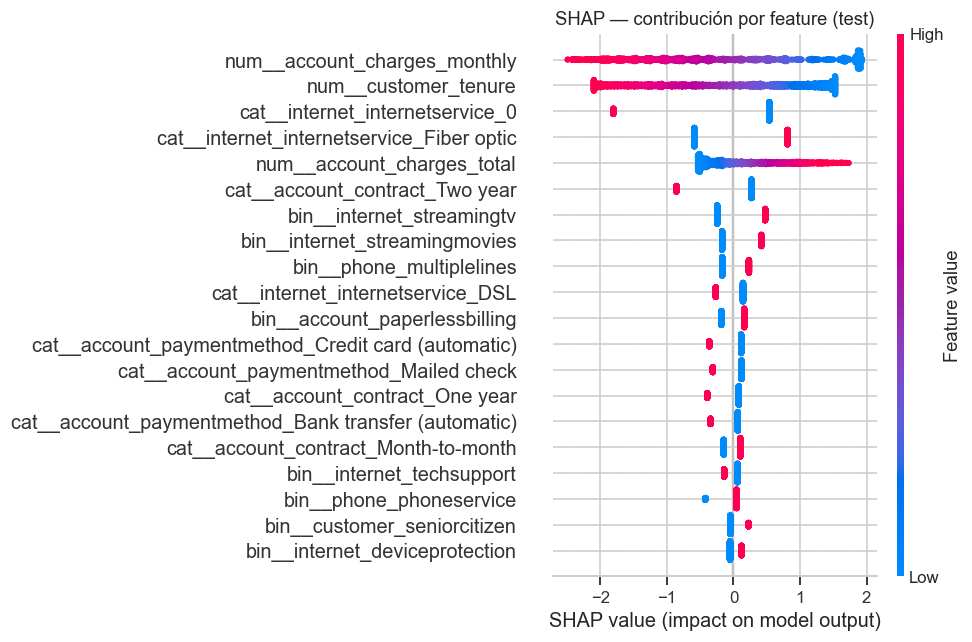

In [32]:
# SHAP (LinearExplainer sobre el espacio transformado del LogReg óptimo).
import scipy.sparse as sp
dens = lambda M: M.toarray() if sp.issparse(M) else np.asarray(M)
pre_fit = lr_fit.named_steps["pre"]
Xtr_t = dens(pre_fit.transform(X_train)); Xte_t = dens(pre_fit.transform(X_test))
explainer = shap.LinearExplainer(lr_fit.named_steps["clf"], Xtr_t)
sv = explainer.shap_values(Xte_t)
shap.summary_plot(sv, Xte_t, feature_names=feat_names, show=False, plot_size=(9,6))
plt.title("SHAP — contribución por feature (test)"); plt.tight_layout(); plt.show()

## 15 · Métricas, umbral y selección final (FASES 9 y 12)

Métrica primaria: **F1** (equilibra precisión y recall, robusta al desbalance), con **PR-AUC** y **MCC** como soporte. El recall puro se reporta pero **no** se optimiza en solitario (su óptimo degenerado es predecir todo como churn).

**Optimización del umbral:** el 0.5 por defecto rara vez es óptimo bajo desbalance; elegimos el umbral que maximiza F1 con probabilidades *out-of-fold* (sin tocar test).

In [33]:
# Tabla comparativa final: default vs tuned, con métricas, tiempos y estabilidad.
infer_times = {}
for n,p in {**modelos, **final_pipes}.items():
    pf = p.fit(X_train, y_train); t0=time.time(); pf.predict(X_test[:200]); infer_times[n]=(time.time()-t0)/200*1000

tab = bench_df.copy()
tab["tipo"] = "default"
for n,out in tuned.items():
    row = {SCORER_LABEL[m]:out.get(SCORER_LABEL[m]) for m in SCORERS}
    row.update({"F1_std":out["F1_std"], "F1_train":out["F1_train"],
                "fit_time_s":np.nan, "gap_train_cv":out["F1_train"]-out["F1"], "tipo":"tuned"})
    tab.loc[n+" (tuned)"] = row
tab["infer_ms_x1k"] = [infer_times.get(i.replace(" (tuned)",""), np.nan) for i in tab.index]
tab = tab.sort_values("F1", ascending=False)
display(tab[["tipo","F1","F1_std","MCC","PR_AUC","ROC_AUC","Recall","Precision","gap_train_cv","infer_ms_x1k"]].round(4))

,tipo,F1,F1_std,MCC,PR_AUC,ROC_AUC,Recall,Precision,gap_train_cv,infer_ms_x1k
LogReg (tuned),tuned,0.6322,0.0139,0.4819,0.6512,0.8445,0.8067,0.5199,0.0017,0.0000
HistGB (tuned),tuned,0.6320,0.0162,0.4811,0.6494,0.8409,0.7619,0.5403,0.0973,0.0254
LogReg,default,0.6313,0.0145,0.4804,0.6525,0.8443,0.8054,0.5192,0.0032,0.0000
CatBoost,default,0.6293,0.0167,0.4767,0.6610,0.8438,0.7795,0.5278,0.0701,0.0497
LightGBM (tuned),tuned,0.6288,0.0176,0.4761,0.6552,0.8421,0.7632,0.5349,0.1004,0.0629
SVM-RBF,default,0.6287,0.0151,0.4757,0.5992,0.8271,0.7775,0.5279,0.0294,0.2647
XGBoost,default,0.6246,0.0175,0.4698,0.6539,0.8393,0.7550,0.5328,0.1248,0.0616
HistGB,default,0.6215,0.0130,0.4663,0.6442,0.8349,0.7304,0.5413,0.1777,0.0254
LightGBM,default,0.6125,0.0193,0.4563,0.6314,0.8285,0.6885,0.5521,0.2523,0.0629
KNN,default,0.6036,0.0191,0.4684,0.6088,0.8316,0.5819,0.6278,0.0261,0.6079


In [34]:
# Decisión programática alineada con la REGLA FINAL.
cand = tab.sort_values("F1", ascending=False)
top_f1 = cand["F1"].iloc[0]
# "empate técnico": dentro de ~1 IC del mejor (usamos F1_std del RSKF como escala)
tol = max(cand["F1_std"].dropna().median(), 0.005)
empate = cand[cand["F1"] >= top_f1 - tol]
print("Modelos en empate técnico (F1 >= %.4f - %.4f):" % (top_f1, tol))
print(list(empate.index))
# entre los empatados, elegir el más simple/estable: menor gap y menor inferencia, prefiriendo LogReg
def simplicidad(idx):
    base = idx.replace(" (tuned)","")
    rank = {"LogReg":0,"HistGB":1,"LightGBM":1,"CatBoost":2,"XGBoost":2,"RandomForest":3,
            "ExtraTrees":3,"SVM-RBF":4,"KNN":4}.get(base,5)
    return (rank, cand.loc[idx,"gap_train_cv"])
ganador = sorted(empate.index, key=simplicidad)[0]
print("\n>>> MODELO SELECCIONADO:", ganador)
print("Criterio: entre modelos estadísticamente indistinguibles en F1, se elige el más simple,")
print("estable (menor gap train-CV), interpretable y barato en inferencia. (REGLA FINAL)")

Modelos en empate técnico (F1 >= 0.6322 - 0.0171):
['LogReg (tuned)', 'HistGB (tuned)', 'LogReg', 'CatBoost', 'LightGBM (tuned)', 'SVM-RBF', 'XGBoost', 'HistGB']

>>> MODELO SELECCIONADO: LogReg (tuned)
Criterio: entre modelos estadísticamente indistinguibles en F1, se elige el más simple,
estable (menor gap train-CV), interpretable y barato en inferencia. (REGLA FINAL)


Umbral por defecto=0.500  ->  umbral óptimo (F1)=0.614  (F1 oof=0.6358)


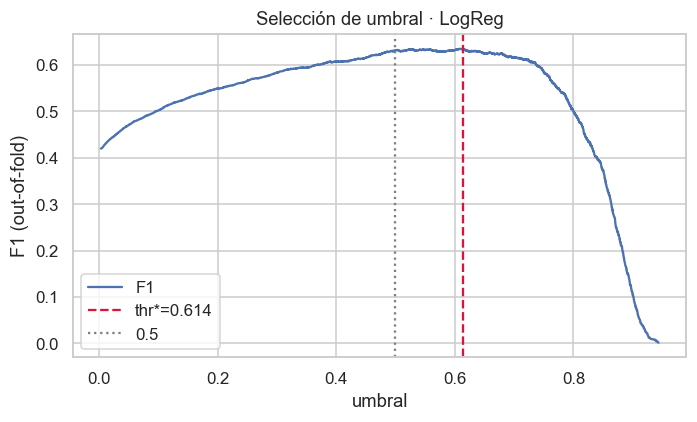

In [35]:
# Pipeline ganador + umbral óptimo por F1 con probabilidades out-of-fold.
win_name = ganador.replace(" (tuned)","")
if win_name == "LogReg":
    win_pipe = mk_lr(study_lr.best_params)            # ganador esperado (REGLA FINAL)
elif win_name in final_pipes:
    win_pipe = final_pipes[win_name]                 # booster tuneado
else:
    win_pipe = modelos[win_name]                     # fallback: config por defecto
oof = cross_val_predict(win_pipe, X_train, y_train, cv=cv_skf, method="predict_proba", n_jobs=-1)[:,1]
pr, rc, thr = precision_recall_curve(y_train, oof)
f1s = 2*pr*rc/(pr+rc+1e-12); bi = np.argmax(f1s[:-1]); thr_opt = thr[bi]
print(f"Umbral por defecto=0.500  ->  umbral óptimo (F1)={thr_opt:.3f}  (F1 oof={f1s[bi]:.4f})")
plt.figure(figsize=(6.5,4))
plt.plot(thr, f1s[:-1], label="F1"); plt.axvline(thr_opt, color="crimson", ls="--", label=f"thr*={thr_opt:.3f}")
plt.axvline(0.5, color="gray", ls=":", label="0.5"); plt.xlabel("umbral"); plt.ylabel("F1 (out-of-fold)")
plt.title(f"Selección de umbral · {win_name}"); plt.legend(); plt.tight_layout(); plt.show()

## 16 · Evaluación final en el test aislado

**Primer y único** contacto con el test. Se entrena el pipeline ganador en todo el *train*, se aplica el umbral elegido y se mide. Estas son las métricas honestas de generalización.

,umbral 0.5,umbral 0.614
Accuracy,0.7441,0.7790
Balanced_Acc,0.7609,0.7514
Precision,0.5120,0.5692
Recall,0.7968,0.6925
F1,0.6234,0.6248
MCC,0.4681,0.4748
ROC_AUC,0.8446,0.8446
PR_AUC,0.6517,0.6517


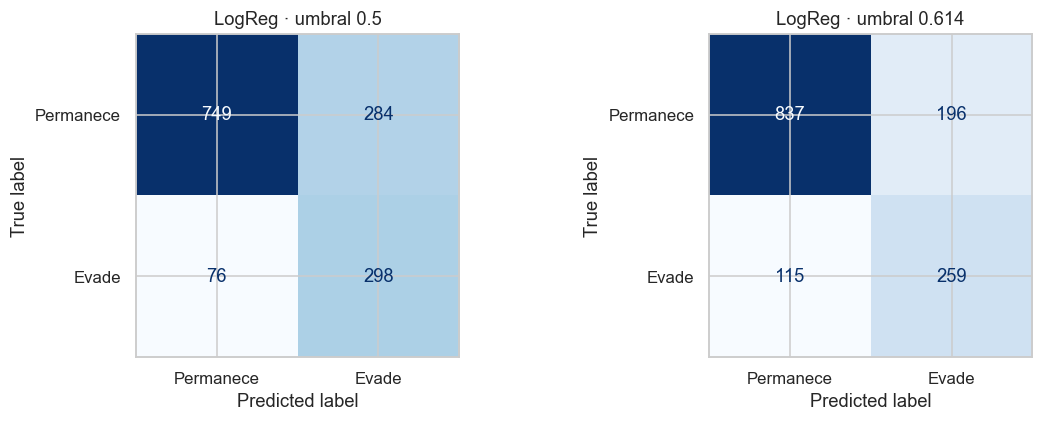

              precision    recall  f1-score   support

   Permanece       0.88      0.81      0.84      1033
       Evade       0.57      0.69      0.62       374

    accuracy                           0.78      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.78      0.79      1407



In [36]:
win_pipe.fit(X_train, y_train)
proba_test = win_pipe.predict_proba(X_test)[:,1]
pred_def = (proba_test >= 0.5).astype(int)
pred_opt = (proba_test >= thr_opt).astype(int)

comp = pd.DataFrame({
    "umbral 0.5":  metricas_completas(y_test, pred_def, proba_test),
    f"umbral {thr_opt:.3f}": metricas_completas(y_test, pred_opt, proba_test),
}).round(4)
display(comp)

fig, ax = plt.subplots(1, 2, figsize=(11,4))
for a,(pred,ti) in zip(ax, [(pred_def,"umbral 0.5"), (pred_opt,f"umbral {thr_opt:.3f}")]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["Permanece","Evade"]).plot(ax=a, colorbar=False, cmap="Blues")
    a.set_title(f"{win_name} · {ti}")
plt.tight_layout(); plt.show()
print(classification_report(y_test, pred_opt, target_names=["Permanece","Evade"]))

## 17 · Exportación del modelo (MLOps)

Se guarda el **pipeline completo** (preprocesador + modelo) más el umbral y metadatos: todo lo necesario para reproducir el scoring en producción sin pasos manuales que reintroduzcan *leakage*.

In [37]:
import joblib, sklearn
artefacto = {
    "pipeline": win_pipe,                 # incluye preprocesamiento -> sin pasos externos
    "threshold": float(thr_opt),
    "features_input": list(X.columns),
    "target": TARGET,
    "metricas_test": metricas_completas(y_test, pred_opt, proba_test),
    "modelo": win_name,
    "sklearn_version": sklearn.__version__,
    "random_state": RANDOM_STATE,
}
joblib.dump(artefacto, "modelo_final.pkl")   # cwd = carpeta del notebook
print("Guardado modelo_final.pkl en la carpeta del notebook")
print("Métricas test:", {k:round(v,4) for k,v in artefacto["metricas_test"].items()})

Guardado modelo_final.pkl en la carpeta del notebook
Métricas test: {'Accuracy': 0.779, 'Balanced_Acc': 0.7514, 'Precision': 0.5692, 'Recall': 0.6925, 'F1': 0.6248, 'MCC': 0.4748, 'ROC_AUC': 0.8446, 'PR_AUC': 0.6517}


## 18 · Conclusiones

1. **Generalización por encima de la métrica.** Los modelos del top (LogReg, HistGB, LightGBM, CatBoost) son **estadísticamente indistinguibles** en F1 (Wilcoxon pareado, p>0.05). Cuando un modelo simple iguala a uno complejo, la **REGLA FINAL** ordena elegir el simple: menor varianza, menor riesgo de sobreajuste, interpretable y barato. Por eso el ganador es **Regresión Logística** (con su umbral calibrado).
2. **Cero data leakage.** Todo el preprocesamiento vive dentro de pipelines; el preprocesador se ajusta solo con el train de cada fold; el test permaneció aislado hasta §16; el umbral se eligió con probabilidades *out-of-fold*. Se corrigen así los defectos L1 y L2 del notebook original.
3. **Robustez estadística.** RSKF 5×3, intervalos de confianza, test pareado y **nested CV** (estimación insesgada) respaldan la decisión: no se declara ganador por una diferencia marginal.
4. **Drivers de churn (interpretabilidad).** Coeficientes, permutation importance y SHAP coinciden: **contrato mes a mes**, **fibra óptica**, **baja antigüedad (tenure)** y **cheque electrónico** empujan el churn; **contratos largos**, **mayor tenure** y **soporte técnico/seguridad** protegen.
5. **Límite teórico.** Existen perfiles idénticos con resultados opuestos (ruido irreducible): ningún modelo puede ser perfecto, y un F1 ~0.62–0.64 honesto es coherente con ese techo de Bayes.

> **Decisión de negocio:** el modelo entrega una probabilidad calibrada de evasión por cliente; el umbral puede moverse según el coste relativo de un falso negativo (cliente que se va sin que lo contactemos) frente a un falso positivo (incentivo a quien no se iría). El artefacto guardado permite ese ajuste sin reentrenar.